# Cls 0b. Compound exercises

Longer problems that combine arrays and plotting and take a bit of thought to structure. They assume
you have worked through `cls0.ipynb`; everything here is an application of the same tools on a larger
scale.

## Ground rules 

- **Vectorize.** Loops over walkers, pixels, or grid points are not acceptable — use array
  operations. A loop over *time steps* is fine and often unavoidable, because step `t+1` depends on
  step `t`.
- **Think in shapes.** Decide the shape of every array before you write the code, and print the
  shapes when something misbehaves. Most bugs here are shape bugs.
- **Check yourself.** Each exercise ends with a *Check* — a quantity with a known value. If yours
  disagrees, you have a bug. Numbers quoted were produced by a reference solution on
  NumPy 2.5.3 / Python 3.12; with the stated seed you should reproduce them closely, and where no
  seed is fixed you should land within sampling noise.

Two exercises are deliberately slow (Exercise 13 integrates seven long orbits, and Exercise 14
integrates a hard problem at three step sizes, the finest being 1.4M steps). Expect a couple of
minutes each; everything else runs in seconds.

### Setup

In [37]:
# Your imports here

import numpy as np
import matplotlib.pyplot as plt


plt.rcParams['figure.figsize'] = (14, 6)

## Part A — Random walks

A 1D random walk takes a `+1` or `-1` step at each tick. It is the simplest model of diffusion, and
its statistics (spreading like `sqrt(t)`, Gaussian endpoint distribution) show up everywhere from
Brownian motion to SGD.

**Exercise 1.** **Simulate an ensemble of walks and plot them.**

* Create a random number generator seeded with `0`, so your run reproduces the numbers quoted below.
* Draw an array of steps with shape `(N, T)` — `N = 200` walkers down the rows, `T = 1000` time steps
  across the columns — where every entry is `+1` or `-1` with equal probability. There is more than
  one way to get `±1` values out of a generator; any of them is fine.
* Turn steps into positions: a walker's position at time `t` is the sum of its first `t` steps. Get
  the whole `(N, T)` array of positions from a **single** cumulative-sum call along the time axis —
  no loop over walkers, no loop over steps.
* Every walk should start at the origin, so prepend a column of zeros. The result has shape
  `(N, T + 1)`.
* Plot the first 60 trajectories on one set of axes. Use thin lines (linewidth around `0.8`) drawn
  with low opacity (alpha around `0.35`) so the density of paths is visible rather than a solid
  block of ink. Draw a black horizontal line at 0, and overlay `+sqrt(t)` and `-sqrt(t)` as dashed
  red curves. Label both axes and give the figure a title.

One trap: handing a 2D array to the plotting routine draws one line per **column**, not per row.
Your trajectories are laid out one per row, so think about what you actually need to pass in.

*Check:* shape is `(200, 1001)` and every walk starts at 0. Roughly two thirds of the endpoints fall
inside the `±sqrt(T)` envelope.

In [34]:
# Your code here

N, T = 200, 1000
rng = np.random.default_rng(seed=0)

# (N, T) -1, 1
# {0, 1} -> *2-1 
step = rng.integers(0, 2, size=(N, T)) * 2 - 1 
pos = step.cumsum(axis=1)
pos = np.concat((np.zeros(N)[:, None], pos), axis=1)

In [35]:
pos.T.shape

(1001, 200)

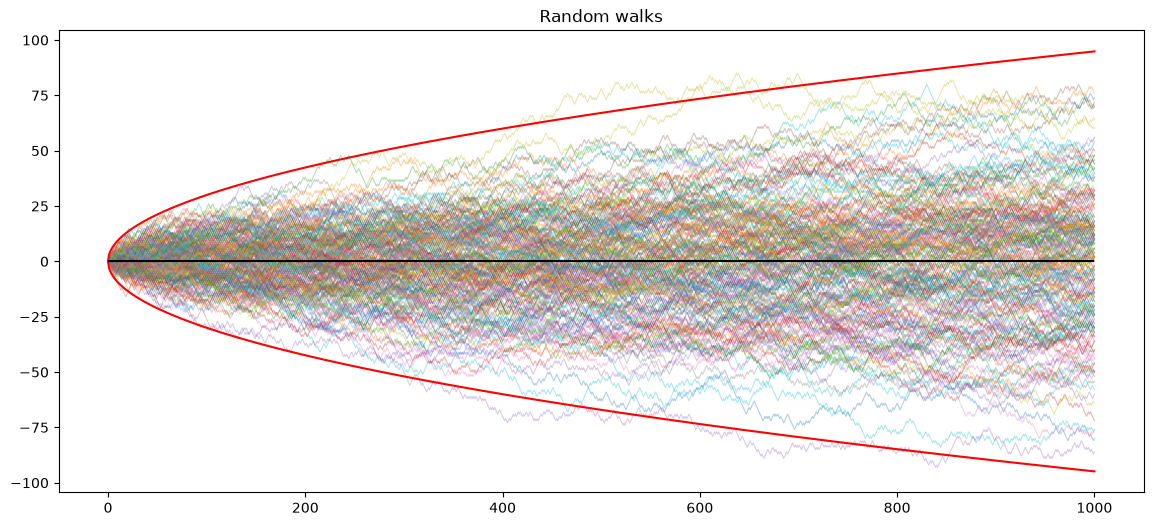

In [53]:
plt.plot(pos.T, lw=0.8, alpha=0.35)


# N(0, sigma^2)
# sigma -- ~66%
# 2 * sigma -- ~95%
# 3 * sigma -- ~99%

t = np.arange(T+1)
plt.plot(t, 3 * np.sqrt(t), c='r')
plt.plot(t, -3 * np.sqrt(t), c='r')

plt.hlines(y=0, xmin=0, xmax=T, colors="black")

plt.title("Random walks")

plt.show()

**Exercise 2.** **Verify the diffusive scaling law.**

The walk spreads like `sqrt(t)`, not like `t`. Measure that exponent instead of taking it on faith.

* Compute the RMS displacement across walkers at each time `t`: square the positions, average over
  the **walker** axis, take the square root. This is a single expression producing a length-`T`
  array.
* Plot it against `t` with both axes on logarithmic scales, and overlay `sqrt(t)` as a dashed
  reference curve.
* Fit a straight line to `log(rms)` against `log(t)` — a degree-1 least-squares polynomial fit — and
  print the slope.

*Check:* the fitted slope is `0.50` (the reference run gives `0.5014`). A slope near `1.0` means you
averaged over the wrong axis.

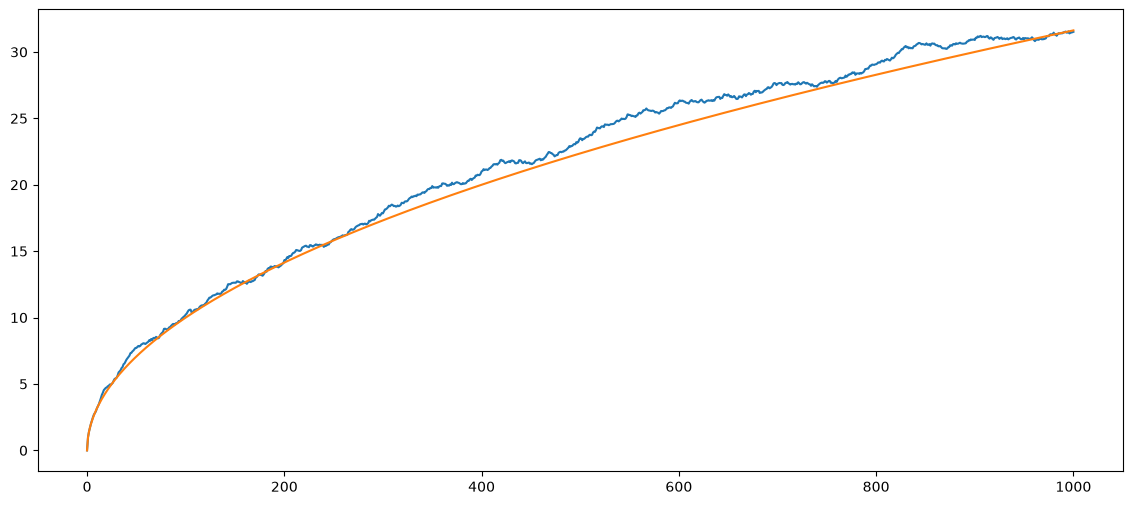

In [60]:
# Your code here
# pos: (N, T)
rms = np.sqrt((pos ** 2).mean(axis=0))
plt.plot(rms)
plt.plot(np.sqrt(t))


# plt.xscale("log")
# plt.yscale("log")


In [59]:
# x, y   
# y ~ a * x + b

In [ ]:
# log(t), log(rms)
# log(rms) ~ a * log(t) + b

# rms ~ sqrt(t)
# log(rms) ~ log(sqrt(t)) = 1/2 * log(t)


a, b = np.polyfit(np.log(t[1:]), np.log(rms[1:]), deg=1)
a, b

(np.float64(0.5014015212227964), np.float64(0.02351711213225761))

/var/folders/18/f0_nd2f14c937fnzhrpz6r8c0000gp/T/ipykernel_47960/1023548698.py:1: RuntimeWarning: divide by zero encountered in log
  plt.plot(a * np.log(t) + b - np.log(rms))
/var/folders/18/f0_nd2f14c937fnzhrpz6r8c0000gp/T/ipykernel_47960/1023548698.py:1: RuntimeWarning: invalid value encountered in subtract
  plt.plot(a * np.log(t) + b - np.log(rms))


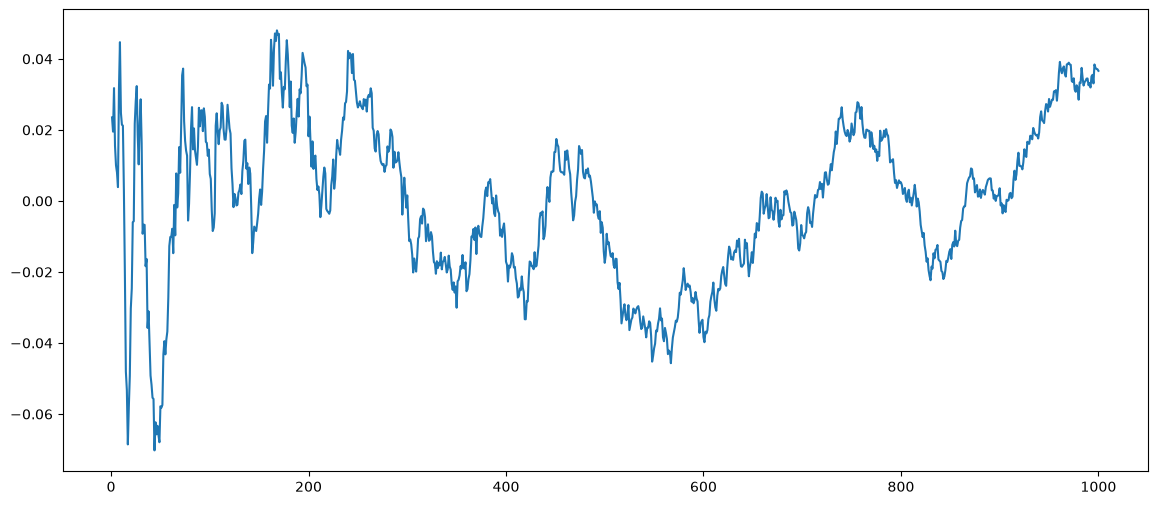

In [69]:
plt.plot(a * np.log(t) + b - np.log(rms))

**Exercise 3.** **Show the endpoint distribution is Gaussian (central limit theorem).**

* Simulate a larger ensemble — `20000` walkers, `T = 1000` steps — and keep only the final positions.
* Histogram them with 60 bins, normalized so that the bar areas integrate to 1 (a density, not raw
  counts) — the plotting library's histogram routine has an option for this.
* Overlay the normal density with mean 0 and standard deviation `sqrt(T)`, evaluated on a fine,
  evenly spaced grid spanning the data. Write the density out yourself rather than importing one:
  `exp(-x**2 / (2 * var)) / sqrt(2 * pi * var)`.
* Print the empirical mean and standard deviation next to the predicted `sqrt(T)`.

*Check:* mean ≈ 0 (reference: `0.04`) and standard deviation ≈ `31.6` (reference: `31.49`,
`sqrt(1000) = 31.62`). Only even endpoints are reachable in `T` even steps, so use enough bins to
avoid comb artifacts, or accept the slight ripple.

In [89]:
# Your code here

N, T = 30_000, 1000
step = rng.integers(0, 2, size=(N, T)) * 2 - 1 
last = step.cumsum(axis=1)[:, -1]


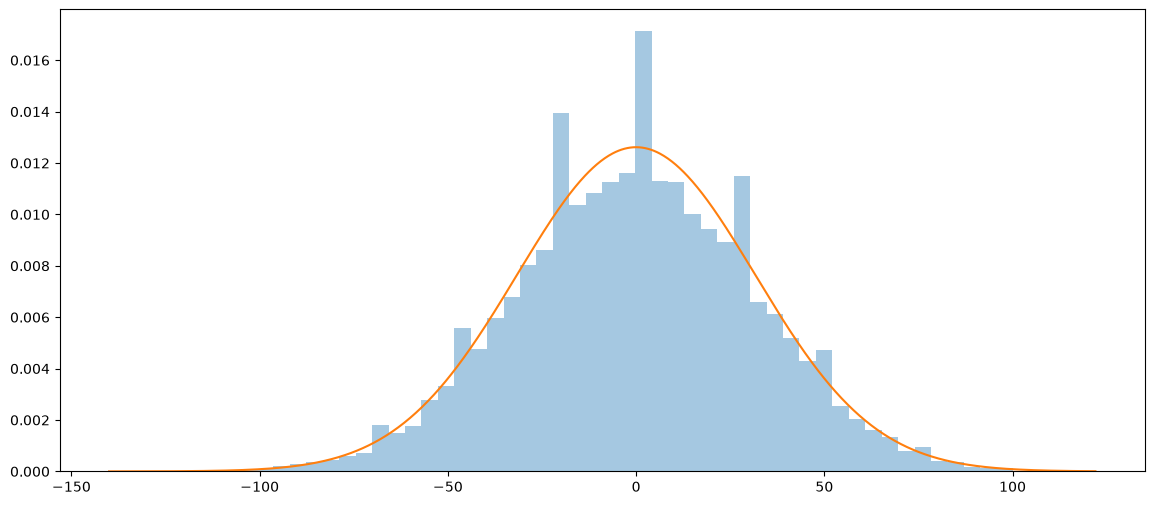

In [90]:
# f(x) = 1 / sqrt(2 * pi * sig^2) * exp(-(x - mu)**2 / 2 * sig^2)
# sig = sqrt(t), mu = 0

x = np.linspace(last.min(), last.max(), 1000)
f = np.exp(-x ** 2 / (2 * T)) / np.sqrt(2 * np.pi * T)

plt.hist(last, bins=60, density=True, alpha=0.4)
plt.plot(x, f)
plt.show()

In [95]:
last.mean(), last.std()

(np.float64(-0.0866), np.float64(31.589168509263846))

**Exercise 4.** **Move to two dimensions.**

* Draw `5000` step directions uniformly from `[0, 2*pi)` and build unit step vectors from them by
  stacking the cosines and the sines into an array of shape `(5000, 2)`. Cumulatively sum along the
  step axis to get the path.
* Plot the path in the plane with a thin line. Force the two axes to the same scale so that the walk
  is not visually distorted — a plot routine that stretches x and y differently makes an isotropic
  walk look anisotropic. Mark the start and end points with two distinguishable markers and add a
  legend.
* Add a second figure: a `2x2` grid of four *independent* walks, each in its own panel, again with
  equal scaling on both axes.
* Print the straight-line distance from the origin to the endpoint.

*Check:* for unit steps in 2D the mean squared displacement equals the number of steps, so typical
endpoint distance is around `sqrt(5000) ≈ 71` — but it fluctuates a lot between runs (the reference
draw gave `99`). Run it a few times to see the spread.

In [103]:
# Your code here

T = 5000
angles = rng.random(size=(T, )) * 2 * np.pi
step = np.stack((np.cos(angles), np.sin(angles)), axis=1)

In [107]:
pos = step.cumsum(axis=0)
pos.shape

(5000, 2)

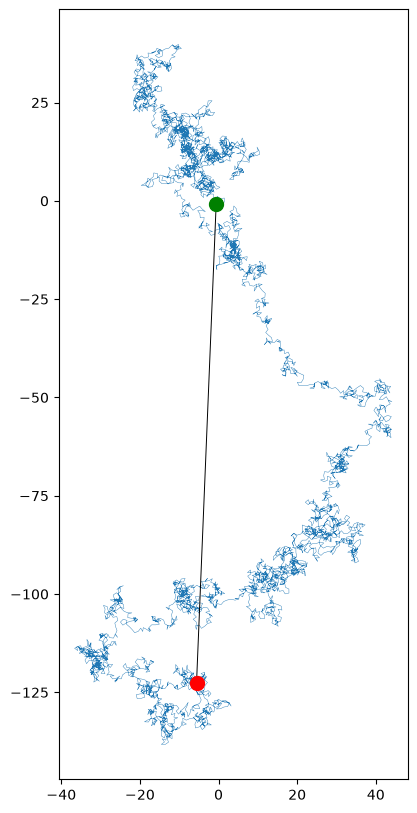

In [136]:
fig, ax = plt.subplots(figsize=(10, 10))

ax.plot(*pos.T, lw=0.3)
ax.scatter(*pos[0], marker='o', c='green', s=100, zorder=3)
ax.scatter(*pos[-1], marker='o', c='red', s=100, zorder=3)
ax.plot((pos[0, 0], pos[-1, 0]), (pos[0, 1], pos[-1, 1]), c="black", lw=0.7)
ax.set_aspect("equal")



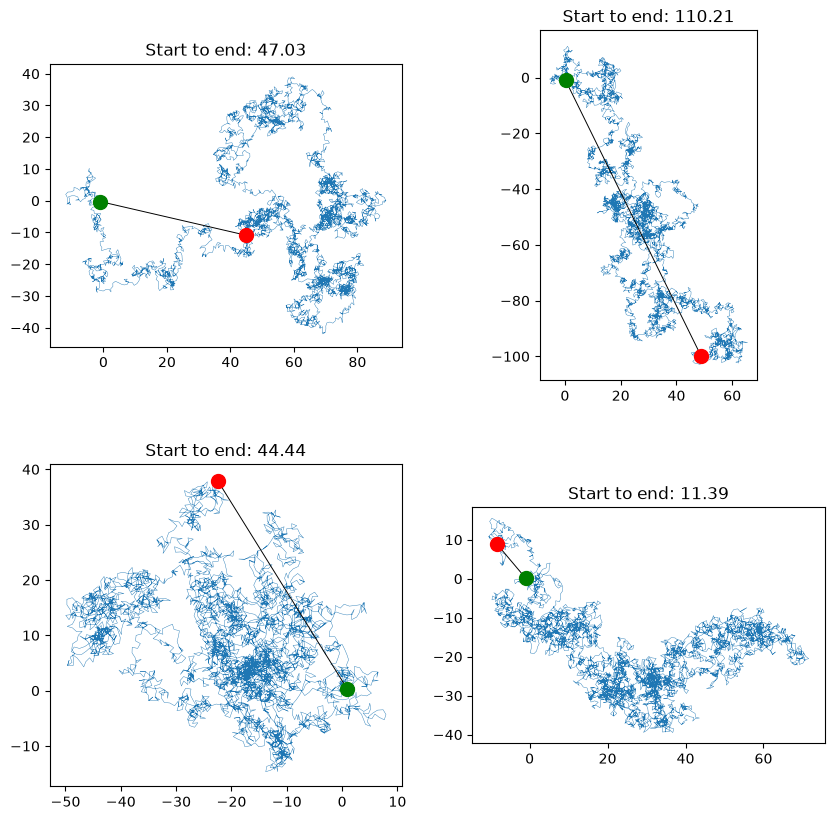

In [151]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

for r in range(axs.shape[0]):
    for c in range(axs.shape[1]):
        ax = axs[r, c]

        angles = rng.random(size=(T, )) * 2 * np.pi
        step = np.stack((np.cos(angles), np.sin(angles)), axis=1)
        pos = step.cumsum(axis=0)

        dist = np.sqrt(np.sum((pos[-1] - pos[0]) ** 2))

        ax.set_title(f"Start to end: {dist:.2f}")
        ax.plot(*pos.T, lw=0.3)
        ax.scatter(*pos[0], marker='o', c='green', s=100, zorder=3)
        ax.scatter(*pos[-1], marker='o', c='red', s=100, zorder=3)
        ax.plot((pos[0, 0], pos[-1, 0]), (pos[0, 1], pos[-1, 1]), c="black", lw=0.7)
        ax.set_aspect("equal")

plt.show()

## Part B — The Mandelbrot set

For each complex `c`, iterate `z -> z**2 + c` starting from `z = 0`. If `|z|` ever exceeds 2 the orbit
escapes to infinity and `c` is outside the set; if it stays bounded, `c` is inside. Coloring each
pixel by *how long* it took to escape produces the familiar image.

The whole point here is doing this over the entire pixel grid at once.

In [163]:
c = 0.9 + 0.5j

In [166]:
T =5 
z = [0]

for _ in range(T):
    z.append(z[-1] ** 2 + c)

z = np.array(z)
z.shape

(6,)

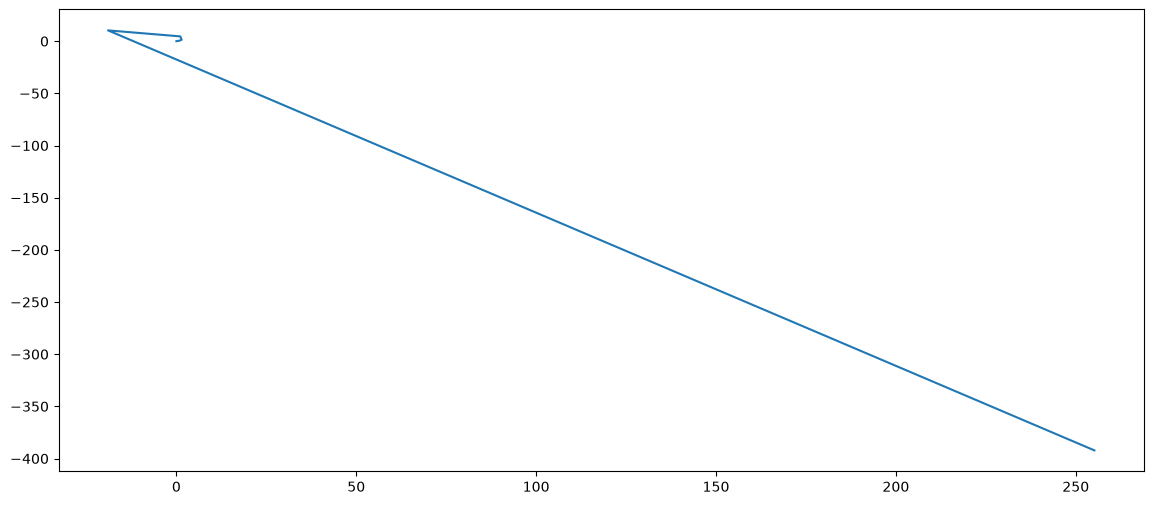

In [167]:
plt.plot(z.real, z.imag)

**Exercise 5.** **Escape-time rendering, fully vectorized.**

* Build a `(600, 600)` grid of complex numbers `c` covering real parts from `-2.2` to `0.8` and
  imaginary parts from `-1.5` to `1.5`. Do it from two 1D arrays of evenly spaced values — one of
  real parts, one of imaginary parts — reshaped so that one is a row and the other a column, and let
  broadcasting expand them into the full grid. No loops, and no explicitly materialized coordinate
  arrays.
* Initialize `z` as an array of complex zeros with the same shape as `c`, an integer array `n` to
  hold the escape iteration of each pixel, and a boolean array `alive` that starts all `True`.
* Loop `maxiter = 200` times. On each pass:
  * update **only the entries that are still alive** — select them with the boolean array on both
    sides of the assignment, and apply `z -> z**2 + c` to that subset;
  * find the entries that escaped on this pass (still alive *and* `|z| > 2`), record the current
    iteration index into `n` for exactly those entries, and clear them from `alive`.
* Points still alive at the end get `n = maxiter`.
* Display `n` as an image. Two display details to get right, both of which are options on the image
  routine: the axes should carry the true mathematical coordinates rather than pixel indices, and the
  image should not come out upside down — by default row 0 of an array is drawn at the *top*, whereas
  your imaginary axis increases *upward*. Add a colorbar and pick a colormap you like.

Updating only the alive entries is not just an optimization: it is what stops escaped points from
overflowing to infinity and flooding your output with runtime warnings.

*Check:* on the real axis the set is exactly the interval `[-2, 0.25]`, so `c = -1` and `c = 0` stay
bounded while `c = 0.3` and `c = -2.5` escape — verify this directly with a plain scalar loop. About
`17%` of pixels on this grid are in the set (reference: `0.169`).

In [173]:
# Your code here

c_re, c_im = np.linspace(-2.2, 0.8, 600), np.linspace(-1.5, 1.5, 600)

c = c_re + 1j * c_im[:, None]

In [191]:
maxiter = 200
z = np.zeros_like(c) 
alive = np.ones_like(c, dtype=bool)
n = np.zeros_like(c, dtype=int)

for i in range(maxiter):
    z[alive] = z[alive] ** 2 + c[alive]

    n[alive & (np.abs(z) > 2)] = i
    alive &= (np.abs(z) < 2)

n[alive] = maxiter

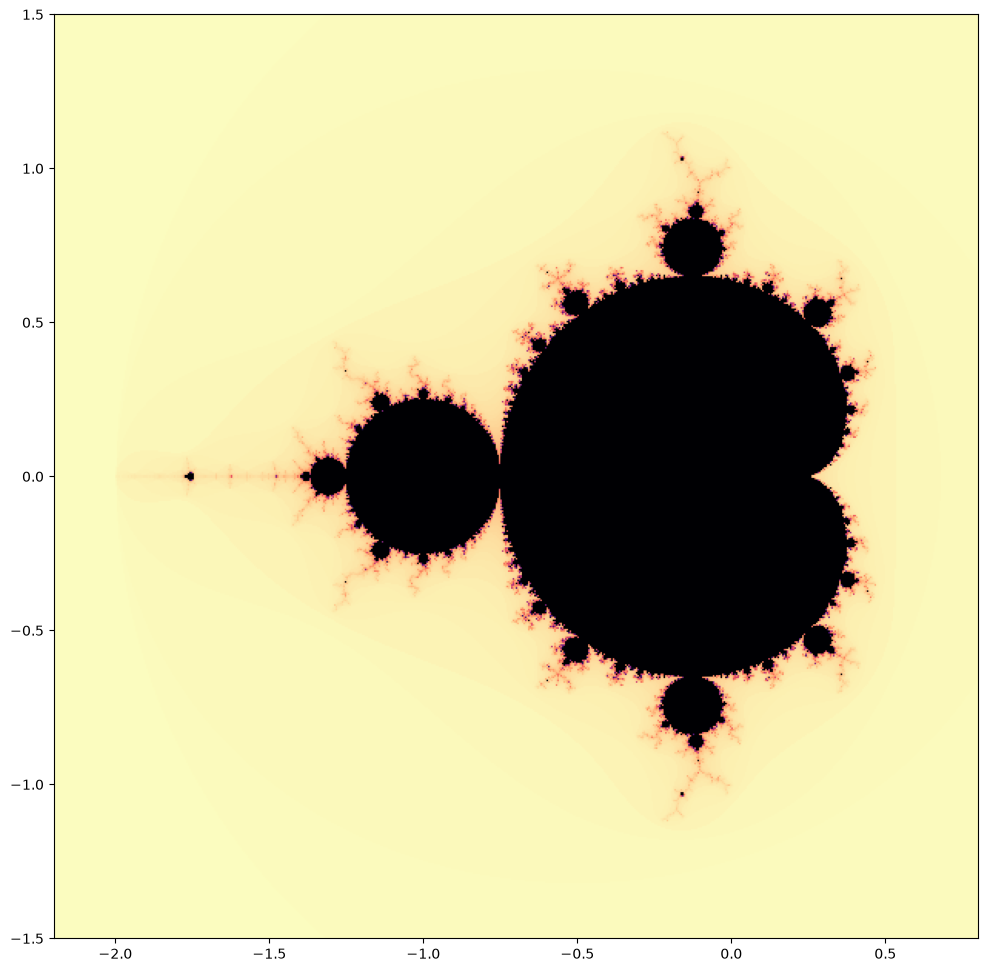

In [198]:
fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(maxiter - n, extent=(-2.2, 0.8, -1.5, 1.5), cmap="magma")

**Exercise 6.** **Smooth (continuous) coloring.**

Integer escape counts produce visible bands. The standard fix is the normalized iteration count
`nu = n + 1 - log(log|z|) / log(2)`, which interpolates between bands using how far past the escape
radius `z` overshot.

* Re-run the iteration, but keep the final `z` values as well as `n`. To make the formula meaningful
  you need `z` *after* it has escaped, so do not clamp or reset it.
* Compute `nu`. Interior points never escaped, so they still have `z = 0` and the formula evaluates
  `log(log(0))` there — which is exactly the kind of invalid operation your array library warns
  about. Suppress those warnings for this one expression (look up how to control floating-point error
  handling locally, as a context manager), then set interior points — the ones still alive — to 0 and
  scrub any remaining non-finite values to 0 as well.
* Plot the banded and smooth versions side by side as two panels of one figure, for comparison.

*Check:* `nu` should be finite everywhere after cleanup and span roughly `0` to `200`
(reference: `0.00` to `199.67`).

In [ ]:
# Your code here

**Exercise 7.** **Zoom in and watch self-similarity.**

* Wrap your renderer in a function `mandelbrot(xlim, ylim, res, maxiter)` returning the iteration
  count array (and the interior mask, which is handy for the check below).
* Render a `(2, 2)` grid of panels centred on `c = -0.743643887037151 + 0.13182590420533j` — a point
  on the boundary in the "seahorse valley" — with half-widths `1.0`, `0.1`, `0.01` and `0.002`. Raise
  `maxiter` as you zoom, because points near the boundary take longer to escape and a deep zoom is
  almost entirely near-boundary; `400` is enough at the deepest level here.
* Title each panel with its half-width, and make sure each panel's axes show true coordinates for
  that panel rather than pixel indices.

*Check:* the deepest panel should show a spiral of miniature copies of the whole set; the reference
run has `1.7%` of pixels in the set there with escape counts spanning `30` to `400`. Because the
coordinates are double-precision floats, this approach visibly breaks down for half-widths below
roughly `1e-15` — the spacing between neighbouring grid points underflows and the "grid" collapses to
a handful of distinct values. Try it: build the coordinate array at half-width `1e-14` and `1e-16`
and count how many of its 500 entries are actually distinct.

In [ ]:
# Your code here

## Part C — Integrating ODEs: from a spring to the three-body problem

Here you will write your own integrator, prove it is correct by measuring its convergence order, and
then use it on gravitational dynamics. The pattern — *build it, validate it on a problem with a known
answer, then trust it on one without* — is the important part.

Everything is written as a first-order system `y' = f(t, y)`. A second-order equation becomes
first-order by stacking positions and velocities into one state vector.

**Exercise 8.** **Write a fourth-order Runge-Kutta integrator.**

* Write `rk4_step(f, t, y, h)` implementing one classical RK4 step:
  `k1 = f(t, y)`, `k2 = f(t + h/2, y + h/2 * k1)`, `k3 = f(t + h/2, y + h/2 * k2)`,
  `k4 = f(t + h, y + h * k3)`, returning `y + h/6 * (k1 + 2*k2 + 2*k3 + k4)`.
* Write `integrate(f, y0, t0, t1, h)` that takes `round((t1 - t0) / h)` steps and returns the array
  of times plus a `(nsteps + 1, len(y0))` array of states. Allocate the output array up front at its
  final size instead of appending to a Python list and converting at the end — you know the size in
  advance, and the later exercises here run millions of steps.
* Make the stepper a parameter of `integrate` with RK4 as the default; Exercise 12 swaps in a
  different one.

Both functions must work for a state vector `y` of any length — do not assume a scalar. Keep them
generic; the next five exercises reuse them unchanged.

*Check:* integrate `y' = y` from `y(0) = 1` to `t = 1` with a small step; you should recover
`e = 2.718281828...` to about ten digits.

In [ ]:
# Your code here

**Exercise 9.** **Validate the integrator and measure its convergence order.**

The harmonic oscillator `y'' = -y` with `y(0) = 1, y'(0) = 0` has the exact solution `y(t) = cos(t)`,
which gives you ground truth.

* Write `f(t, y)` returning `[y[1], -y[0]]` for the state `y = [position, velocity]`.
* Integrate from `t = 0` to `t = 10` for step sizes `h = 0.4, 0.2, 0.1, 0.05, 0.025`, and for each
  record the maximum absolute error against `cos(t)`.
* Plot error against `h` with both axes on logarithmic scales, and fit the slope with a degree-1
  least-squares fit on the logarithms. Overlay an `h**4` reference line anchored at your coarsest
  point.
* Also plot the phase portrait (velocity against position) for the coarsest and finest steps, with
  equal scaling on both axes — the exact solution is a perfect circle, so any drift shows up as a
  visible spiral.

*Check:* the slope should be ≈ `4` — that is what "fourth-order" means, and it is the single best test
that your RK4 has no algebra slips. Reference: slope `4.011`, with errors falling from `1.75e-03` at
`h = 0.4` to `2.58e-08` at `h = 0.025`. A slope near `1` or `2` means one of the `k` terms is wrong.

In [ ]:
# Your code here

**Exercise 10.** **Vectorized gravity, plus a conserved quantity to check it with.**

Write a factory `make_nbody(masses, G=1.0)` returning two functions, for `nb` bodies in 2D with state
layout `y = [all positions..., all velocities...]` (length `4 * nb`):

* `f(t, y)`: split the state in half and reshape each half to `(nb, 2)`. Compute **all** pairwise
  separation vectors at once by broadcasting the position array against itself with an extra axis
  inserted in two different places, giving an `(nb, nb, 2)` array whose `[i, j]` entry is
  `r_j - r_i`. Reduce that to an `(nb, nb)` array of pairwise distances (the Euclidean length along
  the last axis). The diagonal is zero — a body's separation from itself — which would divide by
  zero, so overwrite the diagonal with infinity instead; the self-interaction terms then contribute
  exactly nothing. Sum `G * m_j * d_ij / r_ij**3` over `j` to get accelerations of shape `(nb, 2)`,
  and return the velocities and accelerations concatenated back into a flat state-shaped vector.
  There must be no Python loop over bodies or pairs.
* `energy(y)`: total energy — kinetic `0.5 * sum(m * |v|**2)` minus potential
  `G * m_i * m_j / r_ij` summed over *unordered* pairs. Count each pair exactly once by indexing with
  the row/column indices of the strict upper triangle of the `(nb, nb)` distance matrix — there is a
  helper that generates those index pairs for a given matrix size. Make it work on a whole
  `(nsteps, 4*nb)` trajectory array as well as on a single state: write the slicing and reshaping
  relative to the **last** axis so the leading time axis, if present, just comes along.

Then validate on a two-body circular orbit: two masses of `1` at `(-0.5, 0)` and `(0.5, 0)`, with
velocities `(0, -v)` and `(0, +v)` where `v = sqrt(G * m / (2 * r))` with `r = 1` the separation.
Integrate to `t = 20` with `h = 0.002`, plot the orbits with equal axis scaling, plot the separation
over time, and plot the relative energy error over time.

*Check:* the orbit is circular, so the separation must stay `1.000000` throughout — plot it if in
doubt. Total energy is exactly `-0.5`, conserved to `1.4e-13` relative. Non-constant separation means
your `v` or your acceleration is wrong.

In [ ]:
# Your code here

**Exercise 11.** **The figure-eight three-body choreography.**

Three equal masses can chase each other around a single figure-eight curve forever. This solution was
only discovered numerically in 1993 (Moore) and proved to exist in 2000 (Chenciner and Montgomery).
With `G = 1` and all masses `1`, the initial conditions are:

```
r1 = ( 0.97000436, -0.24308753)      r2 = -r1      r3 = (0, 0)
v3 = (-0.93240737, -0.86473146)      v1 = v2 = -v3 / 2
```

and the period is `T = 6.32591398`.

* Assemble the 12-element state vector in your layout and integrate for 3 periods with `h = 5e-4`.
* Plot all three trajectories on axes with equal scaling, and overplot the three starting positions
  as markers.
* Plot the relative energy error against time in a second panel.
* Print the largest componentwise difference between the state after exactly one period and the
  initial state.

*Check:* all three bodies trace the *same* figure-eight curve, so you should see one curve, not three.
Total energy is `-1.287142`, conserved to about `3e-14` relative over 3 periods. After one period the
state returns to its start to within `1.0e-04` — that residual is the integrator's truncation error,
and shrinking `h` shrinks it.

In [ ]:
# Your code here

**Exercise 12.** **Why the choice of integrator matters.**

* Write an Euler stepper (`y + h * f(t, y)`) with the same signature as your RK4 stepper, so it drops
  straight into `integrate`.
* Integrate the figure-eight for one period with **both** methods at the same `h = 5e-4`, and plot the
  two relative energy errors against time on the same axes, with a logarithmic vertical scale. Add a
  small floor to the error before taking the log so that exactly-zero entries do not vanish.
* Plot the two trajectories side by side, equal scaling on both.

*Check:* RK4 holds energy to `~2e-14` while Euler drifts by `1.5e-02` — twelve orders of magnitude
worse for a cost per step in the same ballpark. Euler's orbit visibly spirals apart. This is why
nobody integrates orbits with Euler's method.

In [ ]:
# Your code here

**Exercise 13.** **Sensitivity to initial conditions.**

* Perturb the x-coordinate of body 1 by `eps` and integrate 10 periods, for
  `eps = 1e-3, 1e-2, 5e-2, 1e-1`. Plot the four perturbed trajectories in a `(2, 2)` grid, and for
  each print the final divergence from the unperturbed run *and* the relative energy error.
* Separately, take `eps = 1e-6` and plot the separation between the perturbed and unperturbed
  trajectories against time with a logarithmic vertical scale, over 20 periods. Print the separation
  at 0, 10 and 20 periods, and their ratio.

*Check and interpretation:* the figure-eight survives surprisingly large perturbations — at
`eps = 5e-2` the orbit is still a recognizable, bounded figure-eight (reference divergence `0.99`,
energy still conserved to `1e-13`). This is not an accident: the figure-eight is one of the rare
three-body solutions that is *linearly stable*. Consequently, with `eps = 1e-6` the separation grows
roughly **linearly** in time, not exponentially — reference: `1e-06` grows to `1.7e-04` after 10
periods and `3.4e-04` after 20, a ratio near 2. If you were expecting textbook exponential chaos
here, this is the exercise's point.

At `eps = 1e-1` the system does break up and a body is ejected — **but** the relative energy error
also explodes to `~3e+02`, so that particular result is a numerical artifact, not physics. Which
brings us to the last exercise in this part.

In [ ]:
# Your code here

In [ ]:
# Your code here

**Exercise 14.** **Watch a fixed-step integrator fail, and diagnose it.**

The Pythagorean (Burrau) problem: masses `3, 4, 5` placed at rest at the vertices of a 3-4-5 right
triangle — `(1, 3)`, `(-2, -1)`, `(1, -1)` — with `G = 1`. The bodies fall together, undergo a series
of violent close encounters, and eventually one is ejected while the other two leave as a binary.

* Integrate to `t = 70` with your fixed-step RK4 at `h = 1e-3`, `2e-4` and `5e-5`. For each `h`, plot
  the trajectories and, underneath, the relative energy error with a logarithmic vertical scale.
  Print the energy drift and the largest coordinate reached. Time each run so you can see what the
  finest step costs.
* Explain what you see in a comment before moving on.
* **Then fix it:** re-solve the same problem with an adaptive-step solver from SciPy's ODE
  integration module. Use its explicit eighth-order Runge-Kutta method (`DOP853`), relative and
  absolute tolerances of `1e-12`, a maximum step of `0.1`, and ask it for a *dense output* — a
  continuous interpolant you can evaluate at arbitrary times rather than only at the steps it happened
  to take. Sample that interpolant on a fine grid of 20000 times and plot trajectories and energy
  error exactly as before. Limit the position axes to about `[-6, 6]` so the interesting region is
  visible instead of being squashed by the ejected body.

*Check:* the fixed-step runs are **garbage** — relative energy error jumps from machine precision to
order `1` at the first close encounter near `t = 2`, ending at `4e+02` to `1e+03`, with bodies flung
out to `|r| ~ 2000`. Shrinking `h` by 20x does not rescue it. The reason is that RK4 with a fixed step
cannot resolve a near-collision, where the force diverges and the timescale collapses. The adaptive
solver conserves energy to `4.6e-09` and gives the correct picture: chaotic interplay near the origin,
then one body ejected on a straight line with the remaining binary recoiling the other way.

The lesson generalizes well past orbital mechanics: **a conserved quantity is the cheapest correctness
test you have.** Without plotting energy you would have believed the first plot.

In [ ]:
# Your code here

## Where to look things up

If an exercise above described an operation you could not name, these are the places to search:

**General**
- Google :)
- Gemini, GPT, Claude or any other LLM you can reach

Note: It's ok to ask LLM how to do sth, it's not ok to feed the excercise text into it and ask for a solution

**NumPy**
- [NumPy reference](https://numpy.org/doc/stable/reference/) — grouped by topic; the routine listings
  (array creation, math, statistics, linear algebra, random sampling) are the fastest way to find a
  function from a description
- [Broadcasting](https://numpy.org/doc/stable/user/basics.broadcasting.html) and
  [indexing](https://numpy.org/doc/stable/user/basics.indexing.html) — the two mechanics most of the
  above depends on

**Matplotlib**
- [pyplot API](https://matplotlib.org/stable/api/pyplot_summary.html) — every plotting call and its
  keyword arguments
- [Example gallery](https://matplotlib.org/stable/gallery/) — search by what the picture looks like,
  then read the code

**SciPy**
- [Integration and ODEs](https://docs.scipy.org/doc/scipy/reference/integrate.html)